# Test nblineage Extension

This notebook tests that the nblineage JupyterLab extension is properly installed and enabled.
- Verify that meme metadata is added to the notebook file

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_api_url = "http://localhost:8888/api"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmp04txkwnu


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251204-164249',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpejfgd4cd')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1764834169.352629 seconds


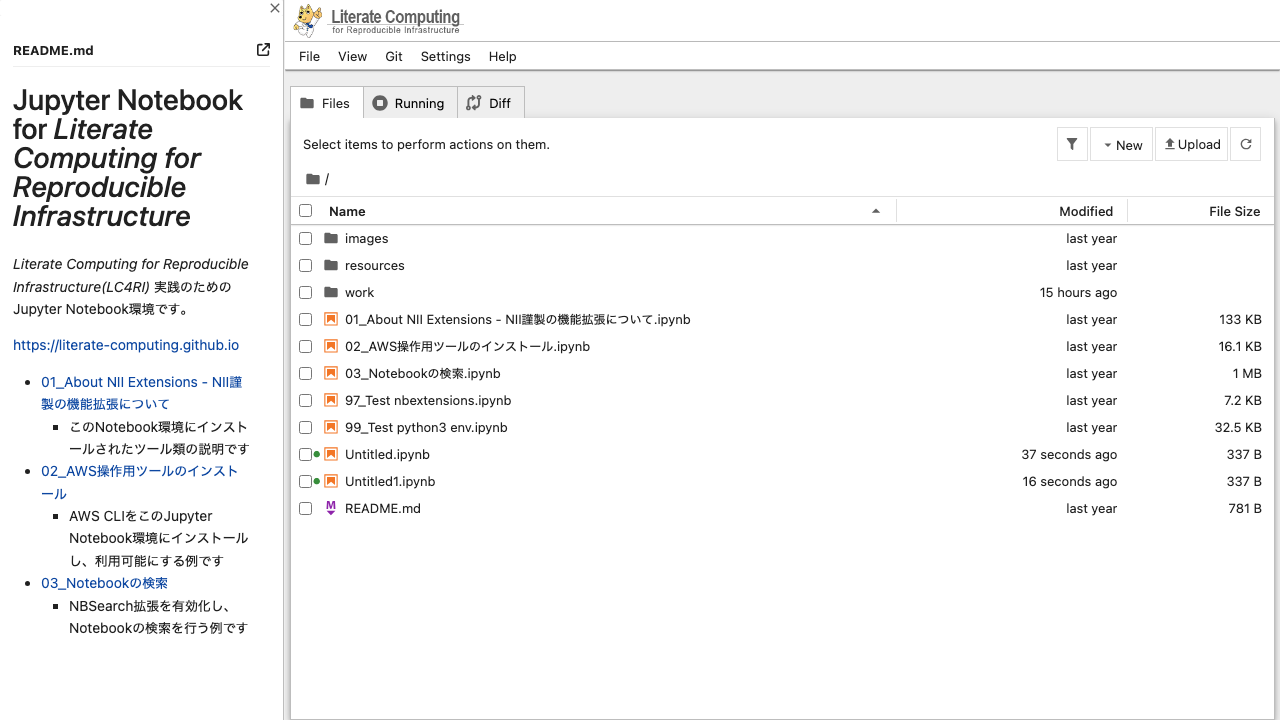

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Create a new notebook

Start epoch: 1764834171.594363 seconds


✓ New notebook created


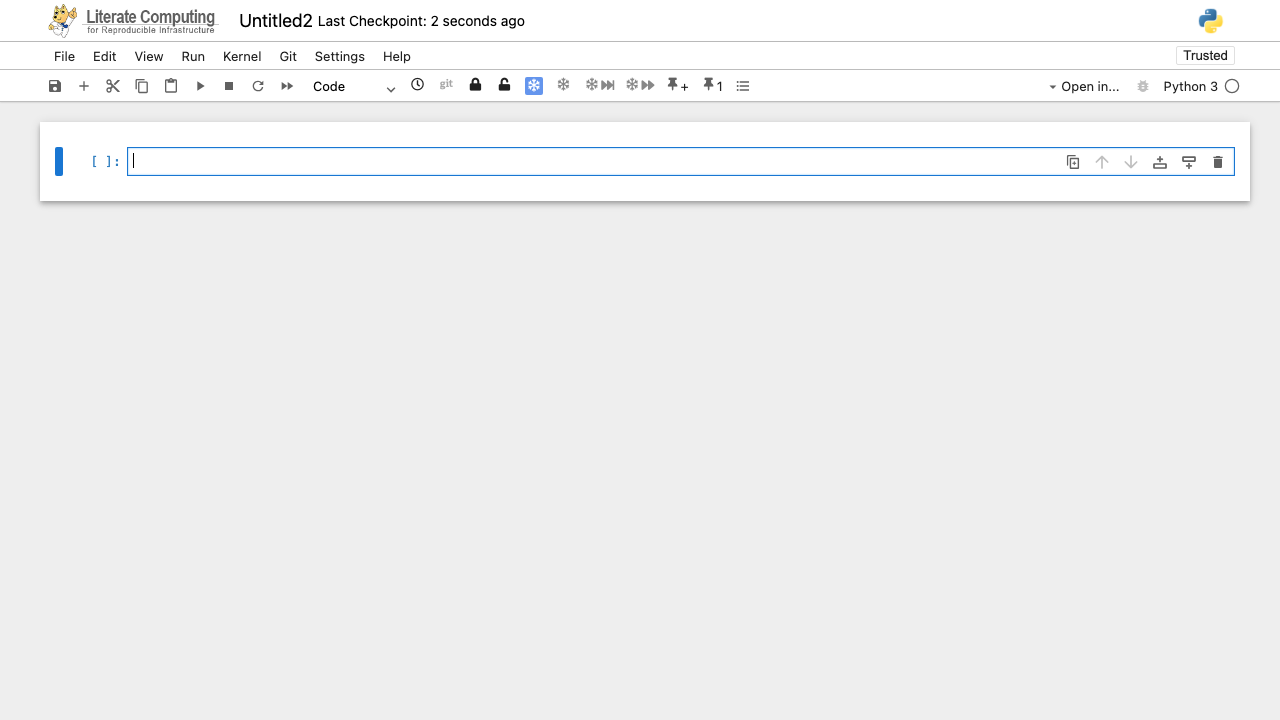

In [6]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Execute a cell to trigger nblineage

Start epoch: 1764834174.3932319 seconds


✓ Cell executed


✓ Notebook saved


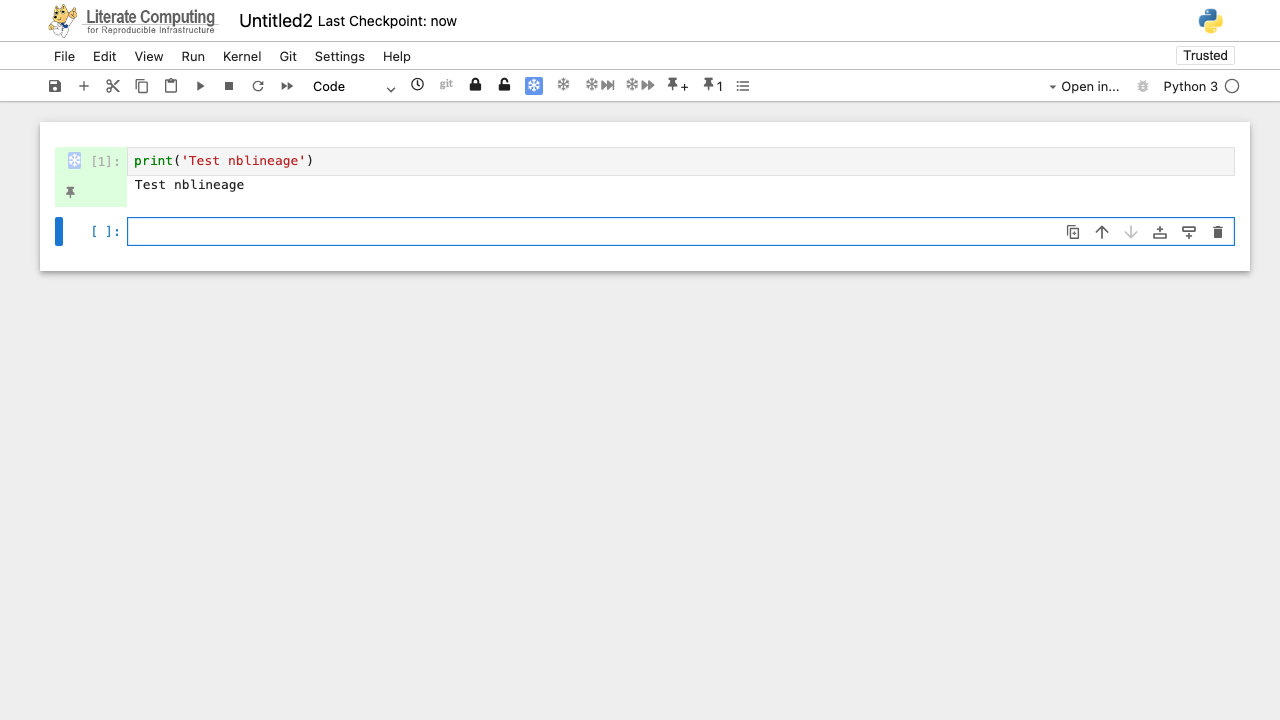

In [7]:
async def _step_execute_cell(page):
    # Create and execute a cell
    await set_cell(page, 0, "code", "print('Test nblineage')", timeout=transition_timeout)
    await run_cell(page, 0, True, timeout=transition_timeout)
    print("✓ Cell executed")
    
    # Save the notebook (Ctrl+S)
    await page.keyboard.press('ControlOrMeta+S')
    await page.wait_for_timeout(1000)
    print("✓ Notebook saved")

await run_pw(_step_execute_cell)

## Verify meme metadata exists in notebook file

Start epoch: 1764834178.727212 seconds
Notebook path: Untitled2.ipynb
✓ API response status: 200
✓ nblineage meme found in notebook metadata
✓ Notebook 'current' is a valid UUID: d7c0c43c-d0e4-11f0-ba70-0242ac110002
✓ First cell 'current' is a valid UUID: d7c0c4c8-d0e4-11f0-ba70-0242ac110002


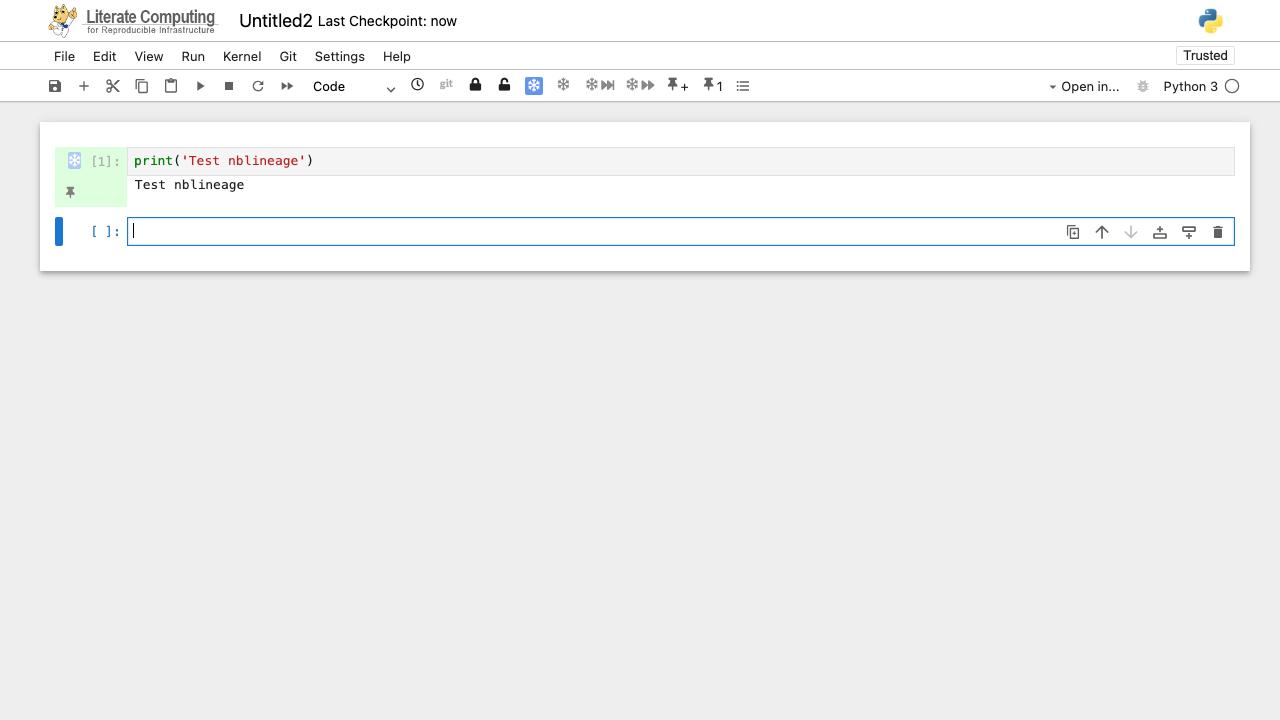

In [8]:
async def _step_verify_meme(page):
    # Get the notebook path from the URL
    url = page.url
    match = re.search(r'/notebooks/(.+\.ipynb)', url)
    if not match:
        raise Exception(f"Could not extract notebook path from URL: {url}")
    
    notebook_path = match.group(1)
    print(f"Notebook path: {notebook_path}")
    
    # Fetch notebook content via Jupyter API
    api_url = f"{jupyter_api_url}/contents/{notebook_path}?token={jupyter_token}"
    response = await page.request.get(api_url)
    print(f"✓ API response status: {response.status}")
    
    notebook_data = await response.json()
    
    # Check if meme exists in the notebook metadata
    assert 'content' in notebook_data, "No content in notebook data"
    assert 'metadata' in notebook_data['content'], "No metadata in notebook content"
    assert 'lc_notebook_meme' in notebook_data['content']['metadata'], "No lc_notebook_meme in notebook metadata"
    
    print("✓ nblineage meme found in notebook metadata")
    
    # Check if current is a valid UUID
    meme = notebook_data['content']['metadata']['lc_notebook_meme']
    assert 'current' in meme, "No 'current' in lc_notebook_meme"
    
    current = meme['current']
    uuid_pattern = r'^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$'
    assert re.match(uuid_pattern, current), f"'current' is not a valid UUID: {current}"
    
    print(f"✓ Notebook 'current' is a valid UUID: {current}")
    
    # Check cell meme
    cells = notebook_data['content']['cells']
    assert len(cells) > 0, "No cells in notebook"
    
    first_cell = cells[0]
    assert 'metadata' in first_cell, "No metadata in first cell"
    assert 'lc_cell_meme' in first_cell['metadata'], "No lc_cell_meme in first cell metadata"
    
    cell_meme = first_cell['metadata']['lc_cell_meme']
    assert 'current' in cell_meme, "No 'current' in lc_cell_meme"
    
    cell_current = cell_meme['current']
    assert re.match(uuid_pattern, cell_current), f"Cell 'current' is not a valid UUID: {cell_current}"
    
    print(f"✓ First cell 'current' is a valid UUID: {cell_current}")

await run_pw(_step_verify_meme)

## Cleanup

In [ ]:
await finish_pw_context()


In [10]:
!rm -rf {work_dir}